# Libraries

In [1]:
# Data Preparation
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
# Data Preprocessing
from transformers import AutoTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
import nltk
import string

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Visualization
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

from tqdm import tqdm

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Device

In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


# Data Preprocessing & Preparation

In [3]:
stop_words_list = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

from transformers import DistilBertTokenizer, DistilBertModel
# Load the DistilBERT tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')

def encode_sentences(sentences, max_len=128):
    """
    Tokenize and encode sentences into BERT embeddings.
    """
    encoded = tokenizer(sentences, padding='max_length', truncation=True, max_length=max_len, return_tensors='pt')
    with torch.no_grad():
        outputs = bert_model(**encoded)
    return outputs.last_hidden_state[:, 0, :]  # Use CLS token as representation

In [4]:
from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

# Preprocessing pipelien
transform_pipeline = preprocessing.Compose([
    preprocessing.Lowercase(),
    preprocessing.Tokenize(tokenizer),
    preprocessing.StopwordsRemoval(stop_words_list),
    preprocessing.POStagging(),
    preprocessing.Lemmatization(lemmatizer), 
])

In [5]:
# 1. Load dataset and apply prior Transform 
train_dataset = IMDBDataset(base_path='aclImdb', size=2000, train=True, transform=transform_pipeline)
test_dataset = IMDBDataset(base_path='aclImdb', size=1000, train=False, transform=transform_pipeline)

# 2. Extract preprocessed texts and labels
train_input = [train_dataset[i][0] for i in range(len(train_dataset))]
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

test_input = [test_dataset[i][0] for i in range(len(test_dataset))]
test_labels = [test_dataset[i][1] for i in range(len(test_dataset))]

# 3. Apply BERT Embeddings to the whole dataset
train_embedded_features = encode_sentences(train_input)
test_embedded_features = encode_sentences(test_input)

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
y_train_tensor = torch.tensor(train_labels, dtype=torch.long)

X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

# 5. Construct dataset for dataloader
train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(X_test_tensor, y_test_tensor)

/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_92561/3759594402.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_92561/3759594402.py:20: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)


# Split data for training and validation

In [6]:
# Split train_dataset into training and validation set
from sklearn.model_selection import train_test_split

#Split dataset for train and validation
train_size = int(0.8 * len(train_dataset))
train_indices, val_indices = train_test_split(list(range(len(train_dataset))),
                                              test_size=len(train_dataset) - train_size,
                                              stratify=y_train_tensor,
                                              random_state=42)

trainset = torch.utils.data.Subset(train_dataset, train_indices)
valset = torch.utils.data.Subset(train_dataset, val_indices)

#DataLoader to handle batching and shuffling
batch_size = 32
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

# Model

# Training + Evaluation

In [7]:
from train_test import train_model, test_model, plot_accuracy_loss
import classifier as clf

# init paramètre
nb_epochs = 64
optimizer = 'Adam'
lr = 0.001

SimpleClassifier(
  (fc1): Linear(in_features=768, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


38552 total parameters.
38552 training parameters.




  6%|▋         | 4/64 [00:00<00:04, 13.79it/s]

| Epoch: [1/64] | Train: Loss 0.6613 Accuracy : 0.6219 | Val: Loss 0.6422 Accuracy : 0.6025

| Epoch: [2/64] | Train: Loss 0.5795 Accuracy : 0.7119 | Val: Loss 0.5811 Accuracy : 0.6725

| Epoch: [3/64] | Train: Loss 0.5343 Accuracy : 0.7381 | Val: Loss 0.5523 Accuracy : 0.7075

| Epoch: [4/64] | Train: Loss 0.5123 Accuracy : 0.7462 | Val: Loss 0.5379 Accuracy : 0.7150

| Epoch: [5/64] | Train: Loss 0.4989 Accuracy : 0.7550 | Val: Loss 0.5299 Accuracy : 0.7300

| Epoch: [6/64] | Train: Loss 0.4890 Accuracy : 0.7700 | Val: Loss 0.5243 Accuracy : 0.7375

| Epoch: [7/64] | Train: Loss 0.4811 Accuracy : 0.7788 | Val: Loss 0.5207 Accuracy : 0.7400



 19%|█▉        | 12/64 [00:00<00:01, 27.05it/s]

| Epoch: [8/64] | Train: Loss 0.4742 Accuracy : 0.7794 | Val: Loss 0.5179 Accuracy : 0.7400

| Epoch: [9/64] | Train: Loss 0.4682 Accuracy : 0.7794 | Val: Loss 0.5154 Accuracy : 0.7375

| Epoch: [10/64] | Train: Loss 0.4626 Accuracy : 0.7819 | Val: Loss 0.5139 Accuracy : 0.7375

| Epoch: [11/64] | Train: Loss 0.4577 Accuracy : 0.7856 | Val: Loss 0.5128 Accuracy : 0.7275

| Epoch: [12/64] | Train: Loss 0.4530 Accuracy : 0.7844 | Val: Loss 0.5116 Accuracy : 0.7250

| Epoch: [13/64] | Train: Loss 0.4486 Accuracy : 0.7900 | Val: Loss 0.5109 Accuracy : 0.7225

| Epoch: [14/64] | Train: Loss 0.4443 Accuracy : 0.7937 | Val: Loss 0.5103 Accuracy : 0.7275

| Epoch: [15/64] | Train: Loss 0.4403 Accuracy : 0.7950 | Val: Loss 0.5100 Accuracy : 0.7300



...

| Epoch: [47/64] | Train: Loss 0.3297 Accuracy : 0.8562 | Val: Loss 0.5447 Accuracy : 0.7375

| Epoch: [48/64] | Train: Loss 0.3258 Accuracy : 0.8550 | Val: Loss 0.5481 Accuracy : 0.7350

| Epoch: [49/64] | Train: Loss 0.3226 Accuracy : 0.8569 | Val: Loss 0.5501 Accuracy : 0.7350

| Epoch: [50/64] | Train: Loss 0.3188 Accuracy : 0.8606 | Val: Loss 0.5521 Accuracy : 0.7300

| Epoch: [51/64] | Train: Loss 0.3150 Accuracy : 0.8625 | Val: Loss 0.5558 Accuracy : 0.7275

| Epoch: [52/64] | Train: Loss 0.3118 Accuracy : 0.8662 | Val: Loss 0.5585 Accuracy : 0.7325

| Epoch: [53/64] | Train: Loss 0.3085 Accuracy : 0.8681 | Val: Loss 0.5625 Accuracy : 0.7300

| Epoch: [54/64] | Train: Loss 0.3057 Accuracy : 0.8700 | Val: Loss 0.5628 Accuracy : 0.7325



 95%|█████████▌| 61/64 [00:01<00:00, 39.30it/s]

| Epoch: [55/64] | Train: Loss 0.3013 Accuracy : 0.8700 | Val: Loss 0.5680 Accuracy : 0.7325

| Epoch: [56/64] | Train: Loss 0.2984 Accuracy : 0.8738 | Val: Loss 0.5703 Accuracy : 0.7350

| Epoch: [57/64] | Train: Loss 0.2945 Accuracy : 0.8756 | Val: Loss 0.5738 Accuracy : 0.7375

| Epoch: [58/64] | Train: Loss 0.2907 Accuracy : 0.8812 | Val: Loss 0.5804 Accuracy : 0.7325

| Epoch: [59/64] | Train: Loss 0.2883 Accuracy : 0.8788 | Val: Loss 0.5805 Accuracy : 0.7325

| Epoch: [60/64] | Train: Loss 0.2842 Accuracy : 0.8819 | Val: Loss 0.5846 Accuracy : 0.7325

| Epoch: [61/64] | Train: Loss 0.2805 Accuracy : 0.8856 | Val: Loss 0.5879 Accuracy : 0.7350

| Epoch: [62/64] | Train: Loss 0.2776 Accuracy : 0.8838 | Val: Loss 0.5933 Accuracy : 0.7325

| Epoch: [63/64] | Train: Loss 0.2743 Accuracy : 0.8862 | Val: Loss 0.5962 Accuracy : 0.7325



100%|██████████| 64/64 [00:01<00:00, 32.27it/s]


| Epoch: [64/64] | Train: Loss 0.2705 Accuracy : 0.8888 | Val: Loss 0.6021 Accuracy : 0.7325


Test accuracy: 0.758


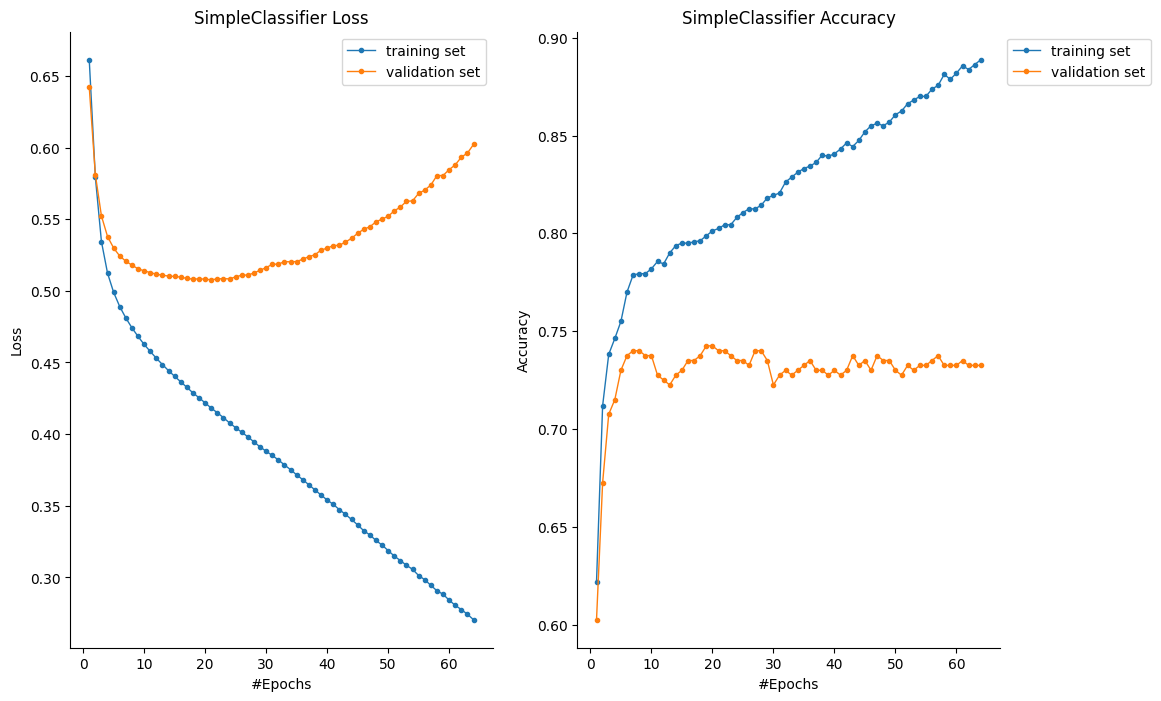

In [8]:
input_dim = train_dataset.tensors[0].shape[1]
model = clf.SimpleClassifier(input_dim=input_dim).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("SimpleClassifier", train_loss, val_loss, train_acc, val_acc)

# LSTM

LSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


592130 total parameters.
592130 training parameters.




  0%|          | 0/64 [00:00<?, ?it/s]

  2%|▏         | 1/64 [00:00<00:10,  6.08it/s]

| Epoch: [1/64] | Train: Loss 0.6656 Accuracy : 0.5931 | Val: Loss 0.5720 Accuracy : 0.7125



  3%|▎         | 2/64 [00:00<00:09,  6.87it/s]

...

| Epoch: [60/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9439 Accuracy : 0.7425

| Epoch: [61/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9499 Accuracy : 0.7425



 98%|█████████▊| 63/64 [00:07<00:00,  8.62it/s]

| Epoch: [62/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9548 Accuracy : 0.7425

| Epoch: [63/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9595 Accuracy : 0.7425



100%|██████████| 64/64 [00:07<00:00,  8.98it/s]


| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.9639 Accuracy : 0.7425


Test accuracy: 0.769


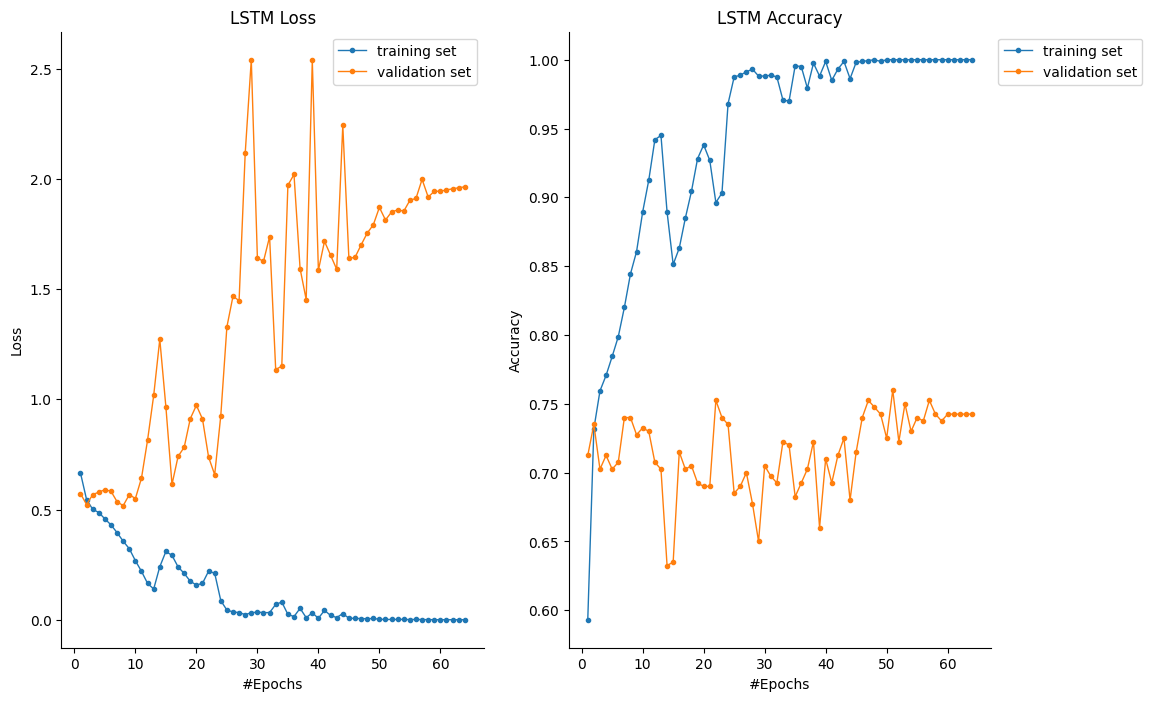

In [9]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMClassifier(input_dim=input_dim, hidden_dim=128, num_layers=2, output_dim=2, bidirectional=False).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("LSTM", train_loss, val_loss, train_acc, val_acc)

# Deeper LSTM

DeepLSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=3, batch_first=True, dropout=0.4, bidirectional=True)
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1726658 total parameters.
1726658 training parameters.




  2%|▏         | 1/64 [00:00<00:17,  3.52it/s]

| Epoch: [1/64] | Train: Loss 0.6921 Accuracy : 0.5106 | Val: Loss 0.6858 Accuracy : 0.5125



  3%|▎         | 2/64 [00:00<00:18,  3.43it/s]

| Epoch: [2/64] | Train: Loss 0.6059 Accuracy : 0.6900 | Val: Loss 0.5758 Accuracy : 0.7250



...

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.5641 Accuracy : 0.7500



 98%|█████████▊| 63/64 [00:25<00:00,  2.48it/s]

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.5730 Accuracy : 0.7500



100%|██████████| 64/64 [00:25<00:00,  2.51it/s]

| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 2.5819 Accuracy : 0.7500


Test accuracy: 0.75


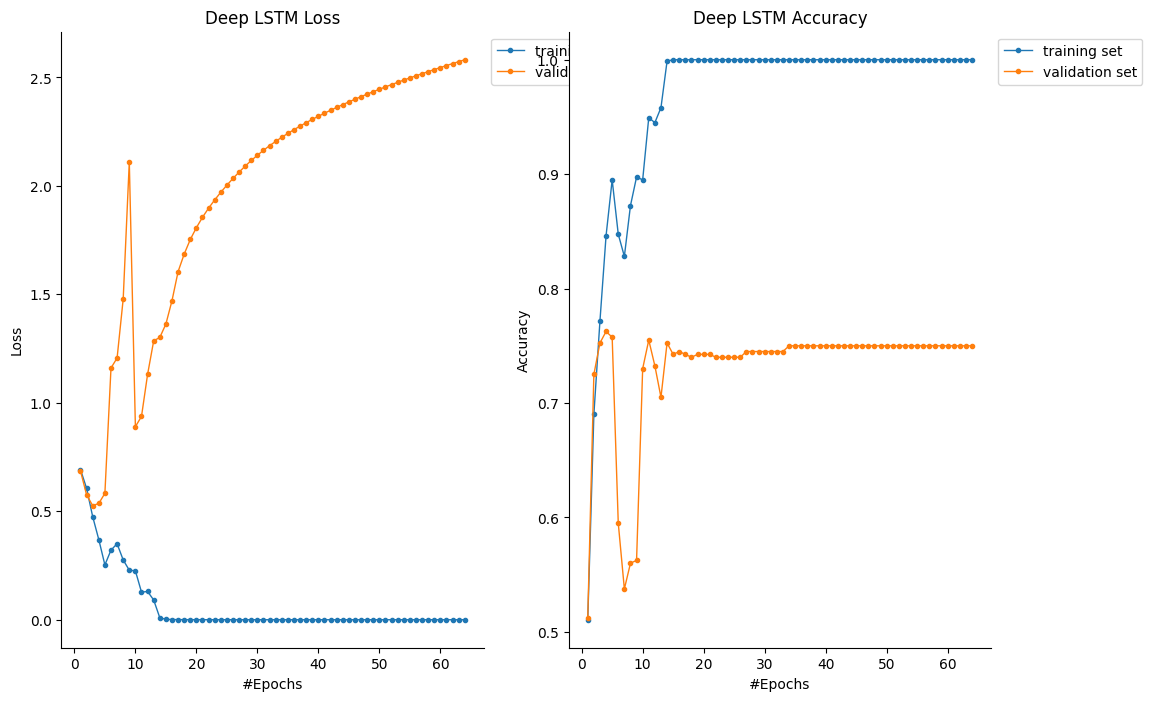

In [10]:
input_dim = X_train_tensor.shape[1]  
model = clf.DeepLSTMClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=3,
    fc_hidden_dim=64,
    output_dim=2,  # set this to the number of classes
    dropout=0.4,
    bidirectional=True
).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Deep LSTM", train_loss, val_loss, train_acc, val_acc)

# Attention LSTM

LSTMWithAttentionClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1331651 total parameters.
1331651 training parameters.




  2%|▏         | 1/64 [00:00<00:22,  2.84it/s]

| Epoch: [1/64] | Train: Loss 0.6759 Accuracy : 0.5737 | Val: Loss 0.5790 Accuracy : 0.7050



  3%|▎         | 2/64 [00:00<00:19,  3.11it/s]

| Epoch: [2/64] | Train: Loss 0.5374 Accuracy : 0.7319 | Val: Loss 0.5165 Accuracy : 0.7350



...

| Epoch: [62/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9367 Accuracy : 0.7600



 98%|█████████▊| 63/64 [00:18<00:00,  3.61it/s]

| Epoch: [63/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9485 Accuracy : 0.7600



100%|██████████| 64/64 [00:18<00:00,  3.38it/s]

| Epoch: [64/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 1.9602 Accuracy : 0.7600


Test accuracy: 0.771


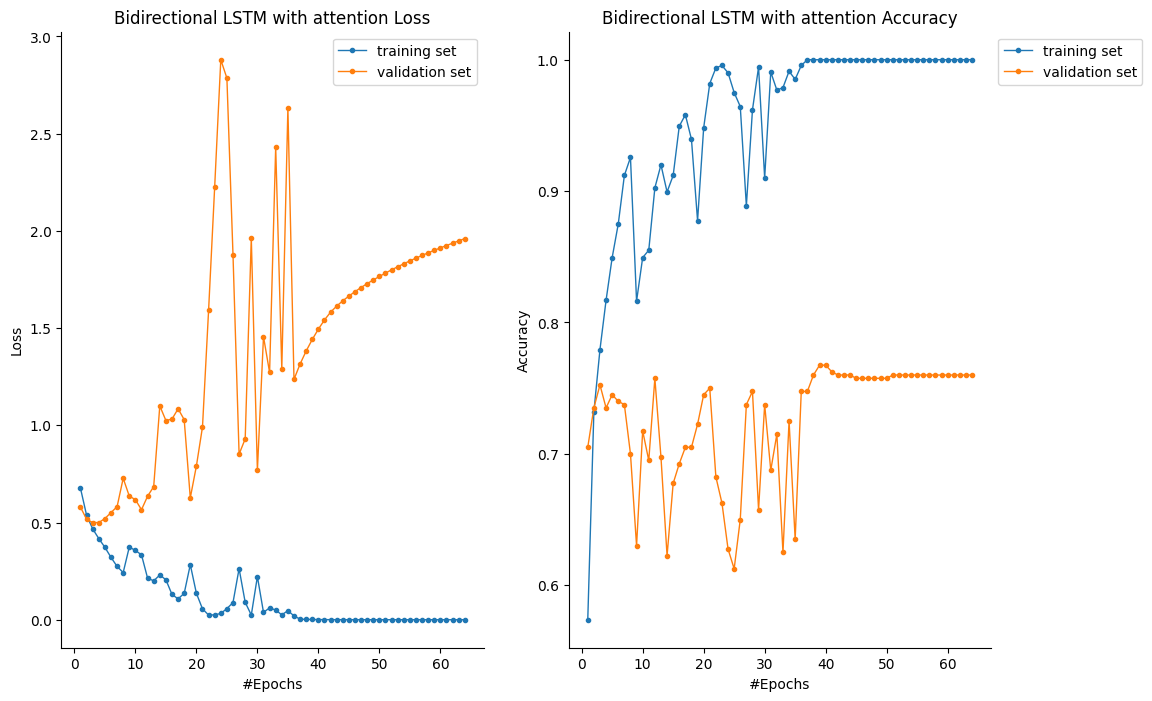

In [11]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMWithAttentionClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=2,
    output_dim=2,
    dropout=0.3,
    fc_hidden_dim=64,
    bidirectional=True
).to(device)


print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Bidirectional LSTM with attention", train_loss, val_loss, train_acc, val_acc)

# MoE

In [14]:
model = clf.MoE(num_experts=3, expert_hidden=128, output_dim=2)
model.to(device)


print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("MoE", train_loss, val_loss, train_acc, val_acc)

MoE(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(in_features

  0%|          | 0/64 [00:00<?, ?it/s]


TypeError: MoE.forward() got an unexpected keyword argument 'x'